# Chest X-Ray Pneumonia Detection using Deep Learning

This project uses deep learning and transfer learning models to automatically detect **Pneumonia from Chest X-Ray images**.

Early detection of pneumonia is important because delayed diagnosis can lead to serious complications. Deep learning models can assist radiologists by providing fast and accurate predictions.

In this project we:

• Load and preprocess chest X-ray images  
• Apply data augmentation  
• Train multiple pretrained CNN models  
• Compare model performance  
• Visualize results

Models Used:
- ResNet18
- MobileNetV3
- EfficientNetB0
- DenseNet121

Goal: Build a reliable deep learning pipeline for medical image classification.

## Import Required Libraries

This section imports all necessary libraries for:

- Data manipulation
- Visualization
- Deep learning
- Model evaluation

Key libraries used:
- PyTorch
- Torchvision
- NumPy
- Pandas
- Matplotlib
- Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Device Configuration

We configure the device to use **GPU if available**, otherwise CPU.

Using GPU significantly speeds up training for deep learning models.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "chest_xray"

## Loading the Chest X-Ray Dataset

The dataset is organized into three folders:

- Train
- Validation
- Test

Each folder contains two classes:

- Normal
- Pneumonia

We use `ImageFolder` from torchvision to automatically assign labels.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [4]:
train_data=datasets.ImageFolder(f"{data_dir}/train",transform=train_transform)
val_data=datasets.ImageFolder(f"{data_dir}/val",transform=val_transform)
test_data=datasets.ImageFolder(f"{data_dir}/test",transform=val_transform)

class_names=train_data.classes

In [5]:
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
val_loader=DataLoader(val_data,batch_size=32)
test_loader=DataLoader(test_data,batch_size=32)

In [6]:
def get_models():
    
    models_dict={}
    
    m1=models.resnet18(weights="IMAGENET1K_V1")
    m1.fc=nn.Linear(m1.fc.in_features,2)
    models_dict["ResNet18"]=m1
    
    m2=models.mobilenet_v3_large(weights="IMAGENET1K_V1")
    m2.classifier[3]=nn.Linear(m2.classifier[3].in_features,2)
    models_dict["MobileNetV3"]=m2
    
    m3=models.efficientnet_b0(weights="IMAGENET1K_V1")
    m3.classifier[1]=nn.Linear(m3.classifier[1].in_features,2)
    models_dict["EfficientnetB0"]=m3
    
    m4=models.densenet121(weights="IMAGENET1K_V1")
    m4.classifier=nn.Linear(m4.classifier.in_features,2)
    models_dict["DenseNet121"]=m4
    
    return models_dict
models_eval=get_models()

In [7]:
def train_model(model, epochs=10):
    model = model.to(device)
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(),lr=0.0003)
    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
    return model

In [8]:
def evaluate(model, loader):
    model.eval()
    preds = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            preds.extend(predicted.cpu().numpy())
            labels_list.extend(labels.numpy())

    return accuracy_score(labels_list, preds)

## Model Performance Comparison

In this section we train all models and compare their performance.

Metrics recorded:

- Validation Accuracy
- Test Accuracy

This allows us to identify the best performing architecture.

In [9]:
results_table = []

for name, model in models_eval.items():

    model = train_model(model)
    val_acc = evaluate(model, val_loader)
    test_acc = evaluate(model, test_loader)

    results_table.append({
        "Model": name,
        "Validation Accuracy": val_acc,
        "Test Accuracy": test_acc
    })

results_df = pd.DataFrame(results_table)
print(results_df)

            Model  Validation Accuracy  Test Accuracy
0        ResNet18               0.8750       0.934295
1     MobileNetV3               0.9375       0.910256
2  EfficientnetB0               1.0000       0.923077
3     DenseNet121               1.0000       0.943910


## Model Accuracy Visualization

Bar charts are used to visually compare the performance of different deep learning models.

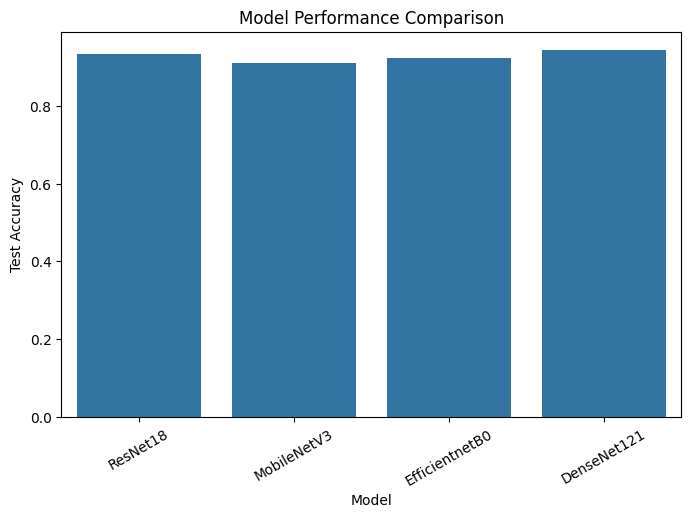

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Test Accuracy")
plt.title("Model Performance Comparison")
plt.xticks(rotation=30)
plt.show()

## Validation vs Test Accuracy

This graph shows how well the model generalizes to unseen data.

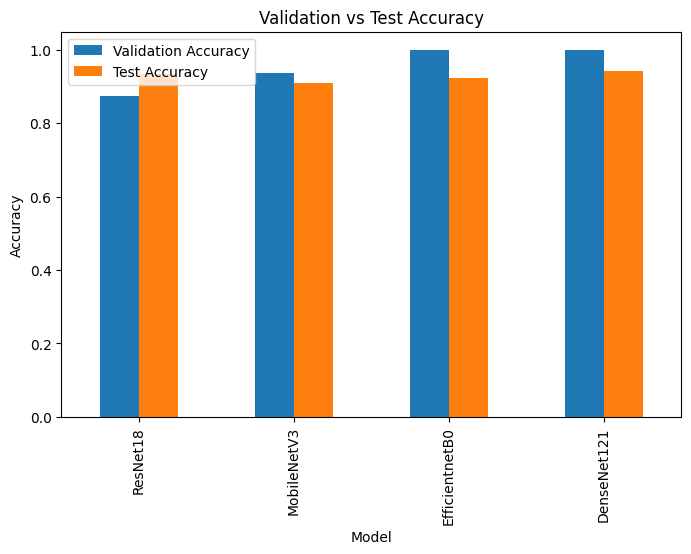

In [11]:
results_df.set_index("Model")[["Validation Accuracy","Test Accuracy"]].plot(
    kind="bar", figsize=(8,5))
plt.title("Validation vs Test Accuracy")
plt.ylabel("Accuracy")
plt.show()

## Dataset Class Distribution

This visualization shows the number of images in each class.

Balanced datasets generally lead to better model performance.

Text(0.5, 1.0, 'Dataset Class Distribution')

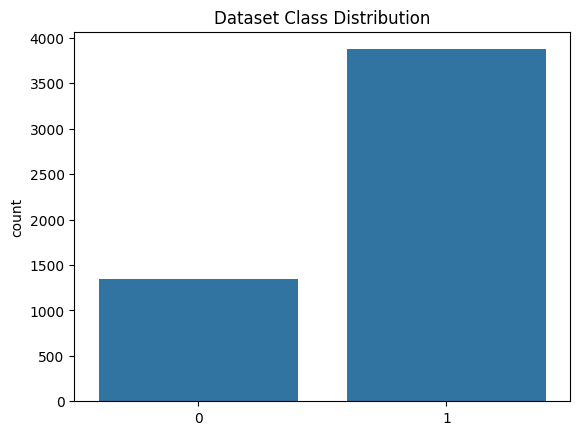

In [12]:
sns.countplot(x=train_data.targets)
plt.title("Dataset Class Distribution")

## Conclusion

This project demonstrates how deep learning can be applied to medical imaging for pneumonia detection.

Key outcomes:

• Multiple CNN models were trained using transfer learning  
• Performance comparison helped identify the best model  
• Visualization improved interpretability  

Future Improvements:

- Add more medical datasets
- Hyperparameter tuning
- Grad-CAM for explainability
- Deploy model as a web application